# The western North America GCOV cube, in use

Notebooks 1–4 built one virtual cube over Mount Rainier and measured what it was worth. This
notebook opens the thing that grew out of them: **every `NISAR_L2_GCOV_PROVISIONAL_V1` granule over
western North America**, indexed into one Icechunk repository as a catalogued collection of
per-track-frame virtual cubes (`nisar_cubes/`, plan in `PLAN_western_north_america_cube.md`).

Three questions, in order: what is in it, does it answer a science question at an arbitrary place
without anyone building anything, and what does that cost.

In [1]:
import sys, time, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))

import numpy as np, pandas as pd, geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import icechunk; icechunk.set_logs_filter("error")

import nisar_cubes as nc

INK, INK2, MUTED = "#1a2226", "#4c5a61", "#c9d1d5"
ACC = ["#0f6b88", "#a9701b", "#2f7a4f", "#7a3b8f"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 10})

t0 = time.perf_counter()
cat = nc.load_catalog()
print(f"catalog: {len(cat)} cubes, {cat.n_times.sum():,} granule-bands, loaded in {time.perf_counter()-t0:.2f}s from {cat.attrs['source']}")

catalog: 1008 cubes, 6,359 granule-bands, loaded in 0.12s from /home/jovyan/nisar_cubes_data/wna/cubes.parquet


## 1. What is in it

One row per cube. A cube is one **track-frame** (relative orbit × frame), one bandwidth mode, one
polarisation set and one band; its time axis is every acquisition of that track-frame on that grid.

In [2]:
summary = (cat.groupby(["band", "mode", "pols"])
              .agg(cubes=("group", "size"), acquisitions=("n_times", "sum"),
                   median_len=("n_times", "median"), longest=("n_times", "max"))
              .sort_values("acquisitions", ascending=False))
display(summary)
print(f"UTM zones: {sorted(cat.epsg.unique())}")
print(f"cubes with >= 10 acquisitions: {(cat[cat.band=='freqA'].n_times >= 10).sum()} of {(cat.band=='freqA').sum()} (freqA)")
print(f"time span: {cat.start.min():%Y-%m-%d} .. {cat.end.max():%Y-%m-%d}")

cubes  acquisitions  median_len  longest
band  mode pols                                          
freqA 4005 DHDH    454          2969         5.0       24
freqB 4005 DHDH    454          2969         5.0       24
      0005 NADV     87           408         5.0       23
freqA 2005 QPDH      4             4         1.0        1
freqB 2005 QPDH      4             4         1.0        1
freqA 2005 DHDH      2             2         1.0        1
freqB 2005 DHDH      2             2         1.0        1
      0005 NASV      1             1         1.0        1

UTM zones: [np.int64(3413), np.int64(32608), np.int64(32609), np.int64(32610), np.int64(32611), np.int64(32612), np.int64(32613), np.int64(32614)]
cubes with >= 10 acquisitions: 54 of 460 (freqA)
time span: 2025-10-29 .. 2026-08-25


Every grid rectangle, coloured by how long its time series is. The archive is not uniform: a few
dozen track-frames have been acquired every cycle since launch commissioning; most have four or five
takes so far. They will all grow — `pixi run nisar-append` adds new acquisitions without rebuilding.

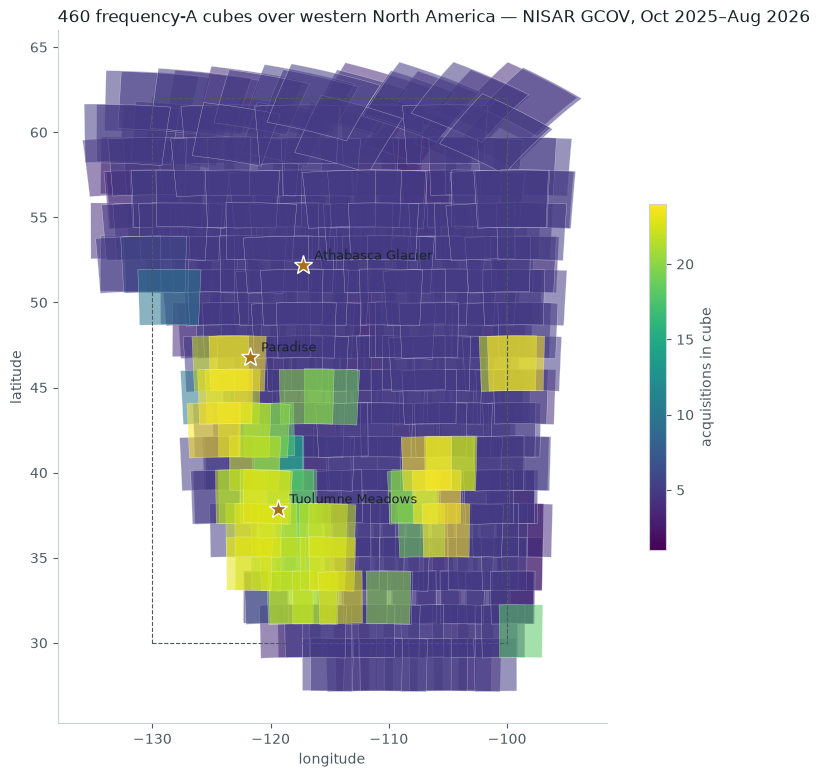

In [3]:
SITES = {
    "Paradise, Mt Rainier (SNOTEL 679)": (-121.7446, 46.7968),
    "Athabasca Glacier, AB": (-117.2400, 52.1900),
    "Tuolumne Meadows, CA (SNOTEL)": (-119.3500, 37.8730),
}
fa = cat[cat.band == "freqA"].sort_values("n_times")
fig, ax = plt.subplots(figsize=(11, 9))
fa.plot(ax=ax, column="n_times", cmap="viridis", alpha=0.55, edgecolor="white", linewidth=0.3,
        legend=True, legend_kwds={"label": "acquisitions in cube", "shrink": 0.5})
for name, (lon, lat) in SITES.items():
    ax.plot(lon, lat, marker="*", ms=14, color=ACC[1], mec="white", mew=1)
    ax.annotate(name.split(",")[0], (lon, lat), xytext=(8, 4), textcoords="offset points", fontsize=9, color=INK)
w, s, e, n = nc.REGIONS["wna"].bbox
ax.add_patch(plt.Rectangle((w, s), e - w, n - s, fill=False, ls="--", color=INK2, lw=0.8))
ax.set_aspect(1 / np.cos(np.deg2rad(46)))
ax.set_title(f"{len(fa)} frequency-A cubes over western North America — NISAR GCOV, {cat.start.min():%b %Y}–{cat.end.max():%b %Y}",
             loc="left", color=INK)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.show()

## 2. A science question at an arbitrary place

The same recipe at three sites nobody built a cube for: find the cubes that *image* the point (not
merely whose grid contains it — failure #8), open the longest, clip a 500 m window, take the median
γ⁰ per date. The Paradise series should reproduce notebook 3.

In [4]:
def series(lon, lat, half=250, channel="HHHH"):
    pt = Point(lon, lat)
    hits = nc.find(pt, catalog=cat)                      # freqA, imaged footprint intersects
    if hits.empty:
        return None, hits
    row = hits.iloc[0]
    ds = nc.open(row)
    aoi = gpd.GeoSeries([pt], crs=4326).to_crs(ds.rio.crs).buffer(half, cap_style=3).to_crs(4326).iloc[0]
    out = {}
    for ch in [c for c in ("HHHH", "HVHV", "VVVV", "VHVH") if c in ds]:
        chip = nc.clip(ds[ch], aoi)
        out[ch] = 10 * np.log10(chip.where(chip > 0)).median(dim=("x", "y")).compute().to_series()
    return pd.DataFrame(out), hits

RESULTS = {}
for name, (lon, lat) in SITES.items():
    t0 = time.perf_counter()
    df, hits = series(lon, lat)
    dt = time.perf_counter() - t0
    RESULTS[name] = (df, hits)
    if df is None:
        print(f"{name}: no cube images this point yet"); continue
    r = hits.iloc[0]
    print(f"{name}: {len(hits)} cubes see it; using {r.group} ({r.n_times} dates, local {r.local_overpass}, "
          f"{'asc' if r.direction=='A' else 'desc'}) — {len(df)} dates in {dt:.1f}s")

Paradise, Mt Rainier (SNOTEL 679): 4 cubes see it; using D172_F065/4005_DHDH/freqA (24 dates, local 19:07, desc) — 24 dates in 6.0s


Athabasca Glacier, AB: 4 cubes see it; using A048_F028/4005_DHDH/freqA (5 dates, local 04:42, asc) — 5 dates in 1.2s


Tuolumne Meadows, CA (SNOTEL): 5 cubes see it; using D042_F069/4005_DHDH/freqA (23 dates, local 18:55, desc) — 23 dates in 1.6s


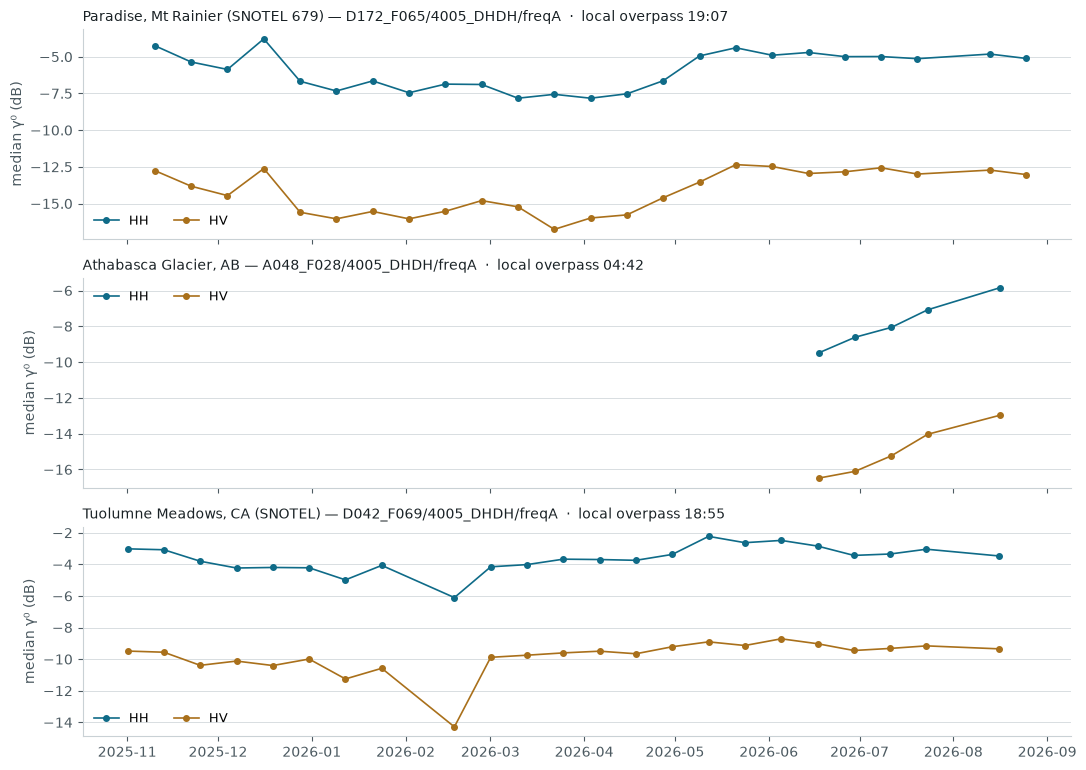

In [5]:
fig, axes = plt.subplots(len(RESULTS), 1, figsize=(11, 2.6 * len(RESULTS)), sharex=True)
for ax, (name, (df, hits)) in zip(np.atleast_1d(axes), RESULTS.items()):
    if df is None:
        ax.text(0.5, 0.5, "no coverage yet", transform=ax.transAxes, ha="center", color=INK2); ax.set_title(name, loc="left"); continue
    for i, ch in enumerate(df.columns):
        ax.plot(df.index, df[ch], marker="o", ms=4, lw=1.2, color=ACC[i], label=ch[:2])
    r = hits.iloc[0]
    ax.set_title(f"{name} — {r.group}  ·  local overpass {r.local_overpass}", loc="left", color=INK, fontsize=10)
    ax.set_ylabel("median γ⁰ (dB)"); ax.legend(frameon=False, ncol=2, fontsize=9)
    ax.grid(axis="y", color=MUTED, lw=0.5)
plt.tight_layout(); plt.show()

Other cubes see each site too — the other look geometries. They are different observations (dawn
vs dusk, ascending vs descending; failure #7), so they are listed rather than pooled.

In [6]:
for name, (df, hits) in RESULTS.items():
    print(name)
    if not hits.empty:
        display(hits[["group", "n_times", "start", "end", "local_overpass", "posting_m"]].reset_index(drop=True))

Paradise, Mt Rainier (SNOTEL 679)


,group,n_times,start,end,local_overpass,posting_m
0,D172_F065/4005_DHDH/freqA,24,2025-11-10 03:18:48,2026-08-25 03:18:47,19:07,10.0
1,A106_F025/4005_DHDH/freqA,5,2026-06-21 13:03:30,2026-08-20 13:03:27,04:54,10.0
2,D071_F065/4005_DHDH/freqA,5,2026-06-19 03:10:31,2026-08-18 03:10:28,19:07,10.0
3,A005_F025/4005_DHDH/freqA,4,2026-06-26 12:55:10,2026-08-13 12:55:07,04:55,10.0


Athabasca Glacier, AB


,group,n_times,start,end,local_overpass,posting_m
0,A048_F028/4005_DHDH/freqA,5,2026-06-17 12:31:55,2026-08-16 12:31:51,04:42,10.0
1,A149_F028/4005_DHDH/freqA,5,2026-06-24 12:40:14,2026-08-23 12:40:11,04:42,10.0
2,D071_F062/4005_DHDH/freqA,5,2026-06-19 03:08:48,2026-08-18 03:08:45,19:19,10.0
3,D143_F062/4005_DHDH/freqA,4,2026-06-24 03:00:29,2026-08-23 03:00:26,19:20,10.0


Tuolumne Meadows, CA (SNOTEL)


,group,n_times,start,end,local_overpass,posting_m
0,D042_F069/4005_DHDH/freqA,23,2025-11-01 02:56:06,2026-08-16 02:56:05,18:55,10.0
1,A034_F021/4005_DHDH/freqA,22,2025-11-24 13:09:32,2026-08-15 13:09:30,05:07,10.0
2,A106_F021/4005_DHDH/freqA,18,2025-12-23 13:01:14,2026-08-20 13:01:11,05:07,10.0
3,D114_F069/4005_DHDH/freqA,18,2025-11-30 02:47:47,2026-08-21 02:47:45,18:54,10.0
4,D114_F070/4005_DHDH/freqA,18,2025-11-30 02:48:21,2026-08-21 02:48:19,18:52,10.0


## 2b. The index is just Zarr — open it with xarray directly

`nc.open` is a convenience. The repository is an ordinary Icechunk store and every cube is an
ordinary Zarr v3 group, so plain `xarray` works too. This is what a user without `nisar_cubes` on
their path would write; the only NISAR-specific parts are the credentials for the chunk references,
which `nc.open_repo()` wires up (an `icechunk.Repository` with both virtual-chunk containers
authorised).

In [7]:
repo = nc.open_repo()                              # icechunk.Repository; scheme="auto" → s3 here
store = repo.readonly_session("main").store
print("snapshots on main:", sum(1 for _ in repo.ancestry(branch="main")))

row = RESULTS["Paradise, Mt Rainier (SNOTEL 679)"][1].iloc[0]
group = f"s3/{row.group}"                          # e.g. s3/D172_F065/4005_DHDH/freqA
ds_raw = xr.open_zarr(store, group=group, consolidated=False, zarr_format=3, chunks={})
ds_raw

snapshots on main: 164


<xarray.Dataset> Size: 248GB
Dimensions:       (time: 24, yCoordinates: 35712, xCoordinates: 36144)
Coordinates:
  * time          (time) datetime64[ns] 192B 2025-11-10T03:18:48 ... 2026-08-...
    ctr           (time) int16 48B dask.array<chunksize=(24,), meta=np.ndarray>
    granule       (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
    coverage      (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
  * yCoordinates  (yCoordinates) float64 286kB 5.32e+06 5.32e+06 ... 4.963e+06
  * xCoordinates  (xCoordinates) float64 289kB 3.348e+05 3.348e+05 ... 6.962e+05
Data variables:
    HHHH          (time, yCoordinates, xCoordinates) float32 124GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    projection    (time) uint32 96B dask.array<chunksize=(1,), meta=np.ndarray>
    HVHV          (time, yCoordinates, xCoordinates) float32 124GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes: (12/19)
    grid_signature:  [35712, 36144, 334805.0, 5320075.0, 10.0]
    epsg:            32610
    band:            freqA
    channels:        ['HHHH', 'HVHV']
    track_frame:     D172_F065
    mode:            4005
    ...              ...
    bounds:          [334800.0, 4962960.0, 696240.0, 5320080.0]
    granules:        ['NISAR_L2_PR_GCOV_004_172_D_065_4005_DHDH_A_20251110T03...
    times:           ['2025-11-10T03:18:48', '2025-11-22T03:18:48', '2025-12-...
    time_sorted:     True
    last_indexed:    2026-08-28T18:12:57Z
    source_urls:     {'s3': 's3://sds-n-cumulus-prod-nisar-products/', 'https...

Three things travel with every cube: a `time` axis with per-step provenance coordinates
(`granule`, `coverage` = full/partial frame, `ctr` = product counter), the `projection` variable with
its CF `grid_mapping` attributes (EPSG code, WKT), and group attributes that hold the grid signature,
orbit metadata and the granule ledger. Per-granule statistics that NISAR writes on each raster
(`mean_value`, `max_value`, …) are deliberately *not* carried — they would describe one granule and
look like they describe the stack.

In [8]:
print("per-time coordinates:", [c for c in ds_raw.coords if "time" in ds_raw[c].dims and c != "time"])
print("granule[0]  :", str(ds_raw.granule.values[0]))
print("coverage    :", "".join(ds_raw.coverage.values))
print("projection  :", {k: ds_raw.projection.attrs[k] for k in ("epsg_code", "grid_mapping_name", "utm_zone_number") if k in ds_raw.projection.attrs})
print("HHHH attrs  :", dict(ds_raw.HHHH.attrs))
print("group attrs :", {k: (v if not isinstance(v, list) or len(v) < 6 else f"[{len(v)} items]") for k, v in ds_raw.attrs.items()})

per-time coordinates: ['ctr', 'granule', 'coverage']
granule[0]  : NISAR_L2_PR_GCOV_004_172_D_065_4005_DHDH_A_20251110T031848_20251110T031923_P05023_N_F_J_001
coverage    : FFFFFFFFFFFFFFFFFFFFFFFF
projection  : {'epsg_code': 32610, 'grid_mapping_name': 'transverse_mercator', 'utm_zone_number': 10}
HHHH attrs  : {'description': 'Covariance between HH and HH', 'grid_mapping': 'projection', 'long_name': 'Geocoded polarimetric covariance term HHHH', 'units': '1', 'valid_min': 0.0}
group attrs : {'grid_signature': [35712, 36144, 334805.0, 5320075.0, 10.0], 'epsg': 32610, 'band': 'freqA', 'channels': ['HHHH', 'HVHV'], 'track_frame': 'D172_F065', 'mode': '4005', 'pols': 'DHDH', 'direction': 'D', 'relative_orbit': 172, 'frame': 65, 'collection': 'NISAR_L2_GCOV_PROVISIONAL_V1', 'crids': ['P05023'], 'posting_m': 10.0, 'bounds': [334800.0, 4962960.0, 696240.0, 5320080.0], 'granules': '[24 items]', 'times': '[24 items]', 'time_sorted': True, 'last_indexed': '2026-08-28T18:12:57Z', 'source_urls': 

And a whole track-frame at once, as a `DataTree` — mode/pols → band → cube. The same call with
`group="s3"` opens the entire region (~2,000 nodes) but takes about five minutes, because every
node's metadata is fetched on its own; the catalog is the fast way to navigate, the tree is the
complete one.

In [9]:
t0 = time.perf_counter()
tree = xr.open_datatree(store, engine="zarr", group="s3/D172_F065", consolidated=False, zarr_format=3, chunks={})
print(f"{len(list(tree.subtree))} nodes in {time.perf_counter()-t0:.1f}s")
tree

4 nodes in 0.4s


<xarray.DataTree>
Group: /
└── Group: /4005_DHDH
    ├── Group: /4005_DHDH/freqA
    │       Dimensions:       (time: 24, yCoordinates: 35712, xCoordinates: 36144)
    │       Coordinates:
    │         * time          (time) datetime64[ns] 192B 2025-11-10T03:18:48 ... 2026-08-...
    │           coverage      (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
    │           granule       (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
    │           ctr           (time) int16 48B dask.array<chunksize=(24,), meta=np.ndarray>
    │         * yCoordinates  (yCoordinates) float64 286kB 5.32e+06 5.32e+06 ... 4.963e+06
    │         * xCoordinates  (xCoordinates) float64 289kB 3.348e+05 3.348e+05 ... 6.962e+05
    │       Data variables:
    │           HHHH          (time, yCoordinates, xCoordinates) float32 124GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    │           projection    (time) uint32 96B dask.array<chunksize=(1,), meta=np.ndarray>
    │           HVHV          (time, yCoordinates, xCoordinates) float32 124GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    │       Attributes: (12/19)
    │           grid_signature:  [35712, 36144, 334805.0, 5320075.0, 10.0]
    │           epsg:            32610
    │           band:            freqA
    │           channels:        ['HHHH', 'HVHV']
    │           track_frame:     D172_F065
    │           mode:            4005
    │           ...              ...
    │           bounds:          [334800.0, 4962960.0, 696240.0, 5320080.0]
    │           granules:        ['NISAR_L2_PR_GCOV_004_172_D_065_4005_DHDH_A_20251110T03...
    │           times:           ['2025-11-10T03:18:48', '2025-11-22T03:18:48', '2025-12-...
    │           time_sorted:     True
    │           last_indexed:    2026-08-28T18:12:57Z
    │           source_urls:     {'s3': 's3://sds-n-cumulus-prod-nisar-products/', 'https...
    └── Group: /4005_DHDH/freqB
            Dimensions:       (time: 24, yCoordinates: 4464, xCoordinates: 4518)
            Coordinates:
              * time          (time) datetime64[ns] 192B 2025-11-10T03:18:48 ... 2026-08-...
                ctr           (time) int16 48B dask.array<chunksize=(24,), meta=np.ndarray>
                coverage      (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
                granule       (time) object 192B dask.array<chunksize=(24,), meta=np.ndarray>
              * yCoordinates  (yCoordinates) float64 36kB 5.32e+06 5.32e+06 ... 4.963e+06
              * xCoordinates  (xCoordinates) float64 36kB 3.348e+05 3.349e+05 ... 6.962e+05
            Data variables:
                HHHH          (time, yCoordinates, xCoordinates) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
                HVHV          (time, yCoordinates, xCoordinates) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
                projection    (time) uint32 96B dask.array<chunksize=(1,), meta=np.ndarray>
            Attributes: (12/19)
                grid_signature:  [4464, 4518, 334840.0, 5320040.0, 80.0]
                epsg:            32610
                band:            freqB
                channels:        ['HHHH', 'HVHV']
                track_frame:     D172_F065
                mode:            4005
                ...              ...
                bounds:          [334800.0, 4962960.0, 696240.0, 5320080.0]
                granules:        ['NISAR_L2_PR_GCOV_004_172_D_065_4005_DHDH_A_20251110T03...
                times:           ['2025-11-10T03:18:48', '2025-11-22T03:18:48', '2025-12-...
                time_sorted:     True
                last_indexed:    2026-08-28T18:13:01Z
                source_urls:     {'s3': 's3://sds-n-cumulus-prod-nisar-products/', 'https...

## 2c. Every track that sees a point

A cube is one look geometry. Most places in the region are seen by two to five track-frames —
ascending and descending, adjacent relative orbits, sometimes the 5 MHz `frequencyB`-only mode —
and each sits on its own grid, so they cannot be one array. What *can* be one array is anything
derived at a site: here, the median γ⁰ per acquisition from every cube that images Paradise,
stacked along a `cube` dimension with the orbit metadata as coordinates.

In [10]:
pt = Point(*SITES["Paradise, Mt Rainier (SNOTEL 679)"])
hits_all = nc.find(pt, catalog=cat, band=None)     # both bands, every track-frame
display(hits_all[["group", "band", "n_times", "start", "end", "direction", "relative_orbit", "local_overpass", "posting_m", "epsg"]].reset_index(drop=True))

def site_series(r, geom, half=250):
    ds = nc.open(r)
    aoi = gpd.GeoSeries([geom], crs=4326).to_crs(ds.rio.crs).buffer(half, cap_style=3).to_crs(4326).iloc[0]
    ch = r.channels[0]
    chip = nc.clip(ds[ch], aoi)
    med = 10 * np.log10(chip.where(chip > 0)).median(dim=("x", "y")).compute()
    return (med.drop_vars([c for c in med.coords if c not in ("time",)])
               .expand_dims(cube=[r.group])
               .assign_coords(band=("cube", [r.band]), channel=("cube", [ch]),
                              direction=("cube", [r.direction]), relative_orbit=("cube", [r.relative_orbit]),
                              frame=("cube", [r.frame]), local_overpass=("cube", [r.local_overpass]),
                              posting_m=("cube", [r.posting_m])))

t0 = time.perf_counter()
stack = xr.concat([site_series(r, pt) for _, r in hits_all.iterrows()], dim="cube", join="outer").rename("gamma0_db")
print(f"{stack.sizes['cube']} cubes x {stack.sizes['time']} distinct dates in {time.perf_counter()-t0:.1f}s")
stack

,group,band,n_times,start,end,direction,relative_orbit,local_overpass,posting_m,epsg
0,D172_F065/4005_DHDH/freqA,freqA,24,2025-11-10 03:18:48,2026-08-25 03:18:47,D,172,19:07,10.0,32610
1,D172_F065/4005_DHDH/freqB,freqB,24,2025-11-10 03:18:48,2026-08-25 03:18:47,D,172,19:07,80.0,32610
2,A106_F025/4005_DHDH/freqB,freqB,5,2026-06-21 13:03:30,2026-08-20 13:03:27,A,106,04:54,80.0,32610
3,A106_F025/4005_DHDH/freqA,freqA,5,2026-06-21 13:03:30,2026-08-20 13:03:27,A,106,04:54,10.0,32610
4,D071_F065/4005_DHDH/freqB,freqB,5,2026-06-19 03:10:31,2026-08-18 03:10:28,D,71,19:07,80.0,32610
5,D071_F065/4005_DHDH/freqA,freqA,5,2026-06-19 03:10:31,2026-08-18 03:10:28,D,71,19:07,10.0,32610
6,A005_F025/4005_DHDH/freqA,freqA,4,2026-06-26 12:55:10,2026-08-13 12:55:07,A,5,04:55,10.0,32611
7,A005_F025/4005_DHDH/freqB,freqB,4,2026-06-26 12:55:10,2026-08-13 12:55:07,A,5,04:55,80.0,32611


8 cubes x 38 distinct dates in 5.0s


<xarray.DataArray 'gamma0_db' (cube: 8, time: 38)> Size: 1kB
array([[-4.248128 , -5.3570247, -5.864847 , -3.7816706, -6.6710687,
        -7.3325963, -6.645894 , -7.453162 , -6.864479 , -6.889743 ,
        -7.8233294, -7.560182 , -7.824233 , -7.524996 , -6.633628 ,
        -4.9429684, -4.389779 , -4.8976526, -4.709837 ,        nan,
               nan, -4.9929447,        nan,        nan,        nan,
        -4.986307 ,        nan,        nan,        nan, -5.1310024,
               nan,        nan,        nan, -4.8177495,        nan,
               nan,        nan, -5.1178484],
       [-2.0810368, -3.3254335, -4.3608327, -2.3623374, -4.948194 ,
        -5.37475  , -4.8045073, -5.8530354, -4.636754 , -5.095726 ,
        -5.8037114, -4.9245486, -5.4362926, -5.1355944, -3.3900056,
        -3.6683571, -2.7135227, -3.26402  , -2.95113  ,        nan,
               nan, -3.3576891,        nan,        nan,        nan,
        -3.4197595,        nan,        nan,        nan, -3.8087046,
               nan,        nan,        nan, -3.6881423,        nan,
               nan,        nan, -3.6315777],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
...
               nan,        nan,        nan, -4.1657267,        nan,
               nan,        nan, -4.846985 ,        nan,        nan,
               nan, -5.0326676,        nan,        nan,        nan,
        -5.4976034,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan, -5.2044034,        nan,        nan,
               nan, -5.5138783,        nan,        nan,        nan,
        -5.621676 ,        nan,        nan,        nan, -5.463779 ,
               nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan, -4.667365 ,        nan,        nan,
               nan, -5.3302355,        nan,        nan,        nan,
        -5.4750156,        nan,        nan,        nan, -5.21047  ,
               nan,        nan,        nan]], dtype=float32)
Coordinates:
  * cube            (cube) object 64B 'D172_F065/4005_DHDH/freqA' ... 'A005_F...
    band            (cube) <U5 160B 'freqA' 'freqB' 'freqB' ... 'freqA' 'freqB'
    channel         (cube) <U4 128B 'HHHH' 'HHHH' 'HHHH' ... 'HHHH' 'HHHH'
    direction       (cube) <U1 32B 'D' 'D' 'A' 'A' 'D' 'D' 'A' 'A'
    relative_orbit  (cube) int64 64B 172 172 106 106 71 71 5 5
    frame           (cube) int64 64B 65 65 25 25 65 65 25 25
    local_overpass  (cube) <U5 160B '19:07' '19:07' '04:54' ... '04:55' '04:55'
    posting_m       (cube) float64 64B 10.0 80.0 80.0 10.0 80.0 10.0 10.0 80.0
  * time            (time) datetime64[ns] 304B 2025-11-10T03:18:48 ... 2026-0...
Attributes:
    description:  Covariance between HH and HH
    long_name:    Geocoded polarimetric covariance term HHHH
    units:        1
    valid_min:    0.0

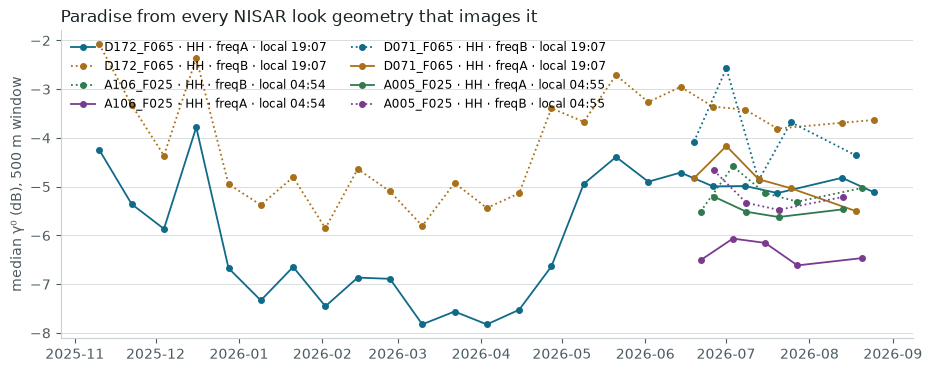

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for i, cube in enumerate(stack.cube.values):
    s = stack.sel(cube=cube).dropna("time")
    ls = "-" if str(stack.band.sel(cube=cube).values) == "freqA" else ":"
    ax.plot(s.time, s, marker="o", ms=4, lw=1.3, ls=ls, color=ACC[i % len(ACC)],
            label=f"{cube.split('/')[0]} · {str(stack.channel.sel(cube=cube).values)[:2]} · {str(stack.band.sel(cube=cube).values)} · local {str(stack.local_overpass.sel(cube=cube).values)}")
ax.set_ylabel("median γ⁰ (dB), 500 m window"); ax.grid(axis="y", color=MUTED, lw=0.5)
ax.legend(frameon=False, fontsize=8.5, ncol=2)
ax.set_title("Paradise from every NISAR look geometry that images it", loc="left", color=INK)
plt.show()

Dawn (ascending, ~05:00 local) and dusk (descending, ~19:00) series are different observations of a
spring snowpack — refrozen versus wet — so they are plotted, not averaged (README failure #7).

If you do want the *imagery* from several tracks on one grid — to compare the same date's scene from
two geometries, say — that is a reprojection, which is a copy, not a view. It is cheap for a chip:
`rioxarray.reproject_match` onto the longest cube's grid.

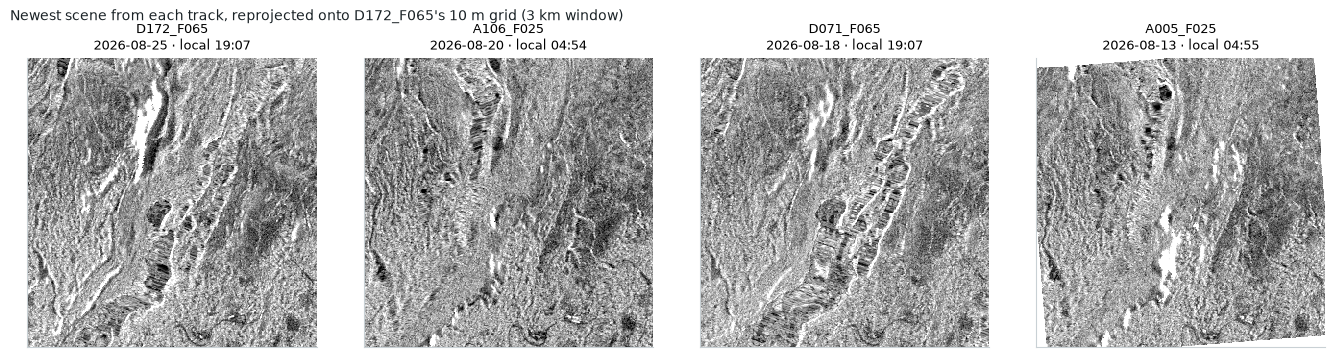

In [12]:
fa = hits_all[hits_all.band == "freqA"]
target = None
chips = []
for _, r in fa.iterrows():
    ds = nc.open(r)
    aoi = gpd.GeoSeries([pt], crs=4326).to_crs(ds.rio.crs).buffer(1500, cap_style=3).to_crs(4326).iloc[0]
    chip = nc.clip(ds[r.channels[0]].isel(time=-1), aoi).compute()
    chip = chip.rio.write_nodata(np.nan)
    if target is None:
        target = chip
    chips.append((r, chip if target is chip else chip.rio.reproject_match(target)))

fig, axes = plt.subplots(1, len(chips), figsize=(3.4 * len(chips), 3.6))
for ax, (r, c) in zip(np.atleast_1d(axes), chips):
    db = 10 * np.log10(c.where(c > 0))
    db.plot(ax=ax, cmap="gray", vmin=-18, vmax=2, add_colorbar=False)
    ax.set_title(f"{r.group.split('/')[0]}\n{pd.Timestamp(c.time.values):%Y-%m-%d} · local {r.local_overpass}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
fig.suptitle(f"Newest scene from each track, reprojected onto {fa.iloc[0].group.split('/')[0]}'s 10 m grid (3 km window)", x=0.01, ha="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

## 3. What it costs

The pieces a user actually pays for, timed. Nothing here built an index; the first person did that
once (about 30 minutes for the whole region).

In [13]:
row = RESULTS["Paradise, Mt Rainier (SNOTEL 679)"][1].iloc[0]
timings = {}
t0 = time.perf_counter(); cat2 = nc.load_catalog(); timings["load catalog (GeoParquet)"] = time.perf_counter() - t0
t0 = time.perf_counter(); hits = nc.find(Point(*SITES["Paradise, Mt Rainier (SNOTEL 679)"]), catalog=cat2); timings["find(point)"] = time.perf_counter() - t0
t0 = time.perf_counter(); ds = nc.open(row); timings[f"open cube ({dict(ds.sizes)})"] = time.perf_counter() - t0
aoi = box(*gpd.GeoSeries([Point(*SITES["Paradise, Mt Rainier (SNOTEL 679)"])], crs=4326).to_crs(ds.rio.crs).buffer(250).total_bounds)
aoi_ll = gpd.GeoSeries([aoi], crs=ds.rio.crs).to_crs(4326).iloc[0]
t0 = time.perf_counter(); chip = nc.clip(ds.HHHH, aoi_ll).compute(); timings[f"read 500 m window x {ds.sizes['time']} dates"] = time.perf_counter() - t0
display(pd.Series(timings, name="seconds").round(2).to_frame())
print(f"logical size of this one cube: {np.prod(ds.HHHH.shape) * 4 * len(ds.data_vars) / 1e12:.2f} TB; bytes read for the window: ~{chip.size * 4 / 1e3:.0f} KB of pixels")

,seconds
load catalog (GeoParquet),0.05
find(point),0.01
"open cube ({'time': 24, 'y': 35712, 'x': 36144})",0.10
read 500 m window x 24 dates,0.38


logical size of this one cube: 0.25 TB; bytes read for the window: ~250 KB of pixels


### Off AWS

The `https/` tree references the same granules over the DAAC's HTTPS endpoint, resolved with an
Earthdata bearer token. Same window, same pixels. (The repository itself currently lives in a
CryoCloud bucket, so a laptop user would additionally need a mirrored copy of the ~1.5 GB index — a
copy, not a rebuild.)

In [14]:
t0 = time.perf_counter()
ds_h = nc.open(row, scheme="https")
chip_h = nc.clip(ds_h.HHHH, aoi_ll).compute()
print(f"https: {time.perf_counter()-t0:.1f}s; identical to the s3 read: {np.array_equal(chip.values, chip_h.values, equal_nan=True)}")

https: 4.3s; identical to the s3 read: True


## What this notebook did not do

It did not reproject, mosaic or resample anything: a cube is one track-frame on its own UTM grid,
and the region is a catalog of them. It did not correct for incidence angle or terrain, and it read
provisional products. What it did do is turn "get me the L-band backscatter history of this point"
into three function calls and a few seconds, anywhere in western North America.